# Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL as Pil

In [2]:
from PIL import Image

In [3]:
files = [
    "images/capybara.jpg",
    "images/capybara_2.jpg",
    "images/capybara_3.jpg",
    "images/cat_1.jpg", 
    "images/cat_2.jpg",
    "images/hamster_1.jpg",
    "images/hamster_2.jpg",
    "images/hamster_3.jpg"
]
M_arr = []
for f in files:
  image = Image.open(f).convert("L")
  image = image.resize((600,600)) # chuan hoa thanh tam anh 600x600, vi nay tim anh co dinh dang khac nen size bi sai
  f_array = np.array(image, dtype=float)
  M_arr.append(f_array)


In [4]:
M = np.array(M_arr)

In [5]:
print(M.shape)


(8, 600, 600)


## 1. Biến dữ liệu thành ma trận


In [6]:
X = M.reshape(len(M),(len(M[0])*len(M[0][0])))

In [7]:
X.shape

(8, 360000)



*   Mỗi hàng trong X biểu diễn một vector tấm ảnh, ở đây 8 hàng là 8 ảnh(sample)
*   Mỗi cột trong X biểu diễn một pixel của tấm ảnh đó, với 360000 pixels cho tấm ảnh 600x600



## 2. Phép toán cơ bản

In [8]:
avg = X.mean(axis = 0)
X_ = X - avg


In [9]:
print(X.shape)

(8, 360000)


In [10]:
print(X_.shape)

(8, 360000)


Broadcasting ko làm thay đổi chiều trước và sau khi broadcast

## 3. Cosine similarity

In [11]:
def cosine_similarity(X, Y = None):
  if Y is None:
    Y = X

  Xn = X/np.linalg.norm(X,axis = 1, keepdims = True)
  Yn = Y/np.linalg.norm(Y,axis = 1, keepdims = True)
  return Xn @ Yn.T

In [12]:
print(cosine_similarity(M[1]))

[[1.         0.99968685 0.99799848 ... 0.91712945 0.91920075 0.92019774]
 [0.99968685 1.         0.99924251 ... 0.92500826 0.92689149 0.9278009 ]
 [0.99799848 0.99924251 1.         ... 0.93655097 0.93815231 0.93896138]
 ...
 [0.91712945 0.92500826 0.93655097 ... 1.         0.99917518 0.99797521]
 [0.91920075 0.92689149 0.93815231 ... 0.99917518 1.         0.999652  ]
 [0.92019774 0.9278009  0.93896138 ... 0.99797521 0.999652   1.        ]]


## 4. Truy vấn

In [35]:
def search(query, top_k=3):
    cosine_list = cosine_similarity(query,X)
    index_list = np.argsort(cosine_list)[0]
    index_list = index_list[::-1]
    
    print("Query khac biet voi",files[index_list[-1]], "nhat.")

    for i in index_list[1:top_k+1]:
      print(files[i], cosine_list[0][i])





## 5. Nhận xét

In [36]:
print(files[4])


images/cat_2.jpg


In [37]:
print(X[4].shape) # la dang [a,b,c]


(360000,)


In [38]:

search(X[4].reshape(1,-1)) # -1 la auto reshape, tu dong chinh tuy y de ve dang [[a,b,c]]

Query khac biet voi images/hamster_3.jpg nhat.
images/hamster_2.jpg 0.931493849991174
images/cat_1.jpg 0.9171772628628786
images/capybara_3.jpg 0.9133921664003755


Tuy bằng trực quan thì cats phải giống nhau nhưng đối với query này, nó chỉ ra cat_2 lại giống hamster_2 nhất và khác hamster_3 nhất

# Bài 2 - Biến đổi tuyến tính & SVD


## 1. Biến đổi tuyến tính


Tạo hình cây thông đơn giản 

In [17]:
H =np.array([
    [1,1],
    [2,1],
    [3,1],
    [4,1],
    [5,1],

    [2,2],
    [3,2],
    [4,2],
    [2.5,3],
    [3.5,3],
    [3,4]

])

Ma trận xoay R và Ma trận co giãn S

In [18]:
R = np.array([
    [np.cos(np.pi/4),np.sin(np.pi/4)],
    [-np.sin(np.pi/4),np.cos(np.pi/4)]
])

S = np.array([
    [2, 0],
    [0, 3]
])


In [19]:
H_ = H@S.T@R.T

Trước khi apply biến đổi tuyến tính

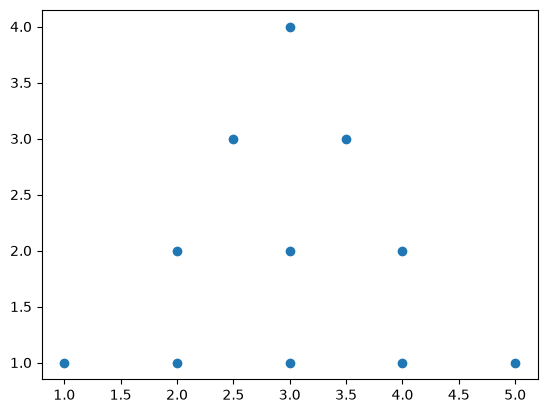

In [20]:
plt.scatter(H[:,0], H[:,1])
plt.show()


Sau khi apply biến đổi tuyến tính

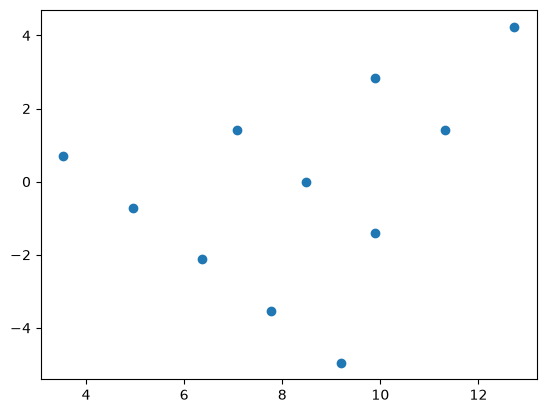

In [21]:
plt.scatter(H_[:,0],H_[:,1])
plt.show()

Nhận xét: Ảnh đã được xoay pi/4 cùng chiều kim đồng hồ và kéo dãn 2 lần phương x và 3 lần phương y

## 2. Nén ảnh bằng SVD

In [22]:
U, S, Vt = np.linalg.svd(M[1], full_matrices=False)

In [23]:
def reconstruct(M,k):
  U,S,Vt = np.linalg.svd(M)
  return (U[:,:k]*S[:k]@Vt[:k,:])

Với k = 5

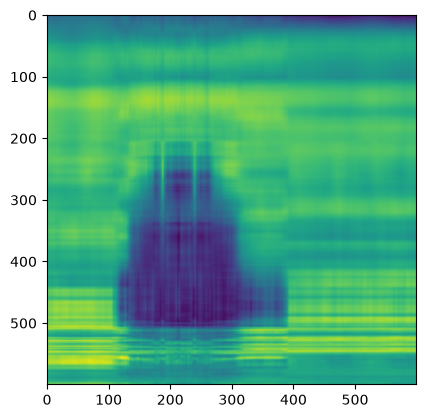

In [24]:
plt.imshow(reconstruct(M[1],5))
plt.show()

Với k = 20

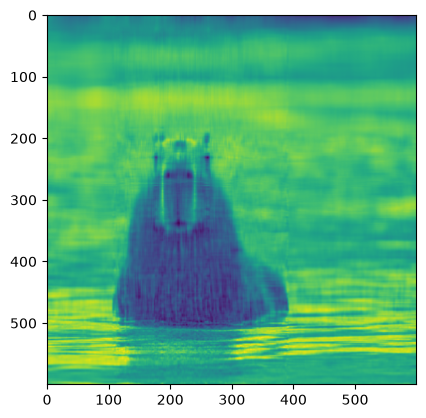

In [25]:
plt.imshow(reconstruct(M[1],20))
plt.show()

Với k = 50

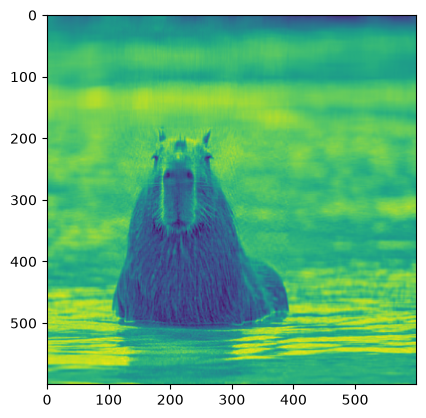

In [26]:
plt.imshow(reconstruct(M[1],50))
plt.show()

## 3. Đánh giá

Tính tỉ lệ nén là tính tỉ số giữa tổng số pixels trước khi nén và tổng số singular values sau khi nén bằng SVD

In [ ]:
def ratio_cal(M,k):
  return (len(M)*len(M[0]))/(len(M)*k+ k+ k*len(M[0]))

In [28]:
print(ratio_cal(M[1],5))

59.950041631973356


Với k = 5, tỉ lệ nén ~ 60 lần 

In [29]:
print(ratio_cal(M[1],20))

14.987510407993339


Với k = 20, tỉ lệ nén ~ 15 lần

In [30]:
print(ratio_cal(M[1],50))

5.995004163197335


Với k = 50,  tỉ lệ nén ~ 6 lần 

Vẽ đồ thị sai số theo k


In [31]:
def error_plot(M,k_list):
  errors = []
  for k in k_list:
    errors.append(np.linalg.norm(M - reconstruct(M,k)))
  plt.scatter(k_list, errors)
  plt.plot(k_list,errors)
  plt.show()

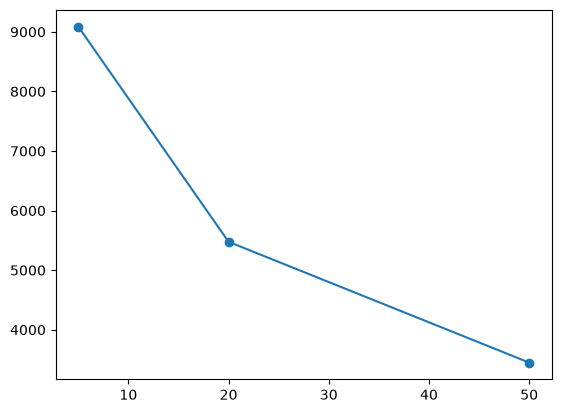

In [32]:
k_list = [5,20,50]
error_plot(M[1],k_list)

## Nhận xét

In [33]:
def percentage(M,k):
  return (np.sum(reconstruct(M,k)**2)/np.sum(M**2)*100)

In [34]:
print(percentage(M[1],5))

99.2158120360743


k nhỏ đến mức mà các dữ liệu trên mức 95% sau khi nén bằng phương pháp SVD, đảm bảo độ sắc nét của ảnh

Trong AI, việc giảm chiều phải chú ý đến tỉ lệ chấp nhận của ảnh, và giá trị kì dị k lấy bao nhiêu để vừa bảo đảm việc giảm chiều hiệu quả, vừa đảm bảo dữ liệu được nén phải ổn định, không bị blurry